# Character-count residual geometry after mean-ablating one attention head

This notebook mean-ablates a configurable attention head and recomputes the cosine-similarity heatmap of average residual-stream activations by true character count.

Mean ablation is performed at `blocks.{ABLATE_LAYER}.attn.hook_z`: the selected head's output vector at every batch and sequence position is replaced with its global mean, estimated on a separate calibration set. The ablated model is then run on an evaluation set, residual activations are grouped by every positive character count possible under the experiment's configured maximum line length, and the global evaluation residual mean is removed before cosine similarities are computed.

In [19]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"

# Select the attention head to mean-ablate (zero-indexed TransformerLens names).
ABLATE_LAYER = 1
ABLATE_HEAD = 3

# Measure the residual stream after this layer. This must be at or downstream
# of the ablated head for the ablation to affect the measurement.
RESIDUAL_LAYER = 1

N_MEAN_SEQUENCES = 2_000
N_EVAL_SEQUENCES = 3_000
COLLECTION_BATCH_SIZE = 128
MEAN_DATA_SEED = 80_801
EVAL_DATA_SEED = 80_802

In [20]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

# A line may spill past its sampled threshold by at most the longest token
# minus one character. Derive all analysis bounds from the saved config.
_, max_line_length = project_data.get_line_length_range(cfg["task"])
max_character_count = max_line_length + cfg["task"]["num_token_lengths"] - 1
CHARACTER_COUNTS = np.arange(1, max_character_count + 1)
N_CHARACTER_COUNTS = len(CHARACTER_COUNTS)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH,
    model=model,
    map_location=device,
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
d_head = cfg["model"]["d_head"]

if not 0 <= ABLATE_LAYER < n_layers:
    raise ValueError(f"ABLATE_LAYER must be in [0, {n_layers - 1}].")
if not 0 <= ABLATE_HEAD < n_heads:
    raise ValueError(f"ABLATE_HEAD must be in [0, {n_heads - 1}].")
if not ABLATE_LAYER <= RESIDUAL_LAYER < n_layers:
    raise ValueError(
        f"RESIDUAL_LAYER must be between ABLATE_LAYER={ABLATE_LAYER} "
        f"and {n_layers - 1}."
    )

ABLATION_SITE = f"blocks.{ABLATE_LAYER}.attn.hook_z"
RESIDUAL_SITE = f"blocks.{RESIDUAL_LAYER}.hook_resid_post"

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Mean-ablating head {ABLATE_HEAD} at {ABLATION_SITE}")
print(f"Measuring residual activations at {RESIDUAL_SITE}")

Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Mean-ablating head 3 at blocks.1.attn.hook_z
Measuring residual activations at blocks.1.hook_resid_post


## Estimate the head's mean output

The calibration mean is computed over all batch and sequence positions. It is estimated from data that is separate from the evaluation set used for the heatmap.

In [21]:
@torch.no_grad()
def estimate_mean_head_output(
    n_sequences: int,
    *,
    batch_size: int = COLLECTION_BATCH_SIZE,
    seed: int = MEAN_DATA_SEED,
) -> torch.Tensor:
    """Estimate E[z] for the selected head over tokens and sequences."""
    head_sum = torch.zeros(d_head, dtype=torch.float64)
    n_head_vectors = 0

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )

        def accumulate_selected_head(z, hook):
            # z shape: [batch, position, head, d_head]
            nonlocal n_head_vectors
            selected = z[:, :, ABLATE_HEAD, :].detach().cpu().double()
            head_sum.add_(selected.sum(dim=(0, 1)))
            n_head_vectors += selected.shape[0] * selected.shape[1]

        model.run_with_hooks(
            batch.tokens,
            prepend_bos=False,
            fwd_hooks=[(ABLATION_SITE, accumulate_selected_head)],
        )

    if n_head_vectors == 0:
        raise RuntimeError("No head activations were collected.")

    return (head_sum / n_head_vectors).float()


mean_head_output = estimate_mean_head_output(N_MEAN_SEQUENCES)
assert mean_head_output.shape == (d_head,)

print("Mean head-output shape:", tuple(mean_head_output.shape))
print(f"Mean head-output norm: {mean_head_output.norm().item():.4f}")

Mean head-output shape: (32,)
Mean head-output norm: 4.3114


## Run the mean-ablated model and collect residual activations

In [22]:
def character_counts_for_tokens(token_rows: torch.Tensor) -> torch.Tensor:
    """Return the running character count at every sequence position."""
    all_counts = []

    for token_row in token_rows.detach().cpu().tolist():
        running_count = 0
        row_counts = []

        for token_id in token_row:
            if token_id == vocab.newline_id:
                running_count = 0
            else:
                token_name = vocab.decode_token(token_id)
                running_count += project_data.extract_character_count(token_name)
            row_counts.append(running_count)

        all_counts.append(row_counts)

    return torch.tensor(all_counts, dtype=torch.long)


@torch.no_grad()
def collect_mean_ablated_residuals(
    n_sequences: int,
    *,
    batch_size: int = COLLECTION_BATCH_SIZE,
    seed: int = EVAL_DATA_SEED,
) -> tuple[np.ndarray, np.ndarray]:
    """Collect residual vectors while the selected head is mean-ablated."""
    residual_chunks = []
    count_chunks = []

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )
        counts = character_counts_for_tokens(batch.tokens)
        saved = {}

        def mean_ablate_selected_head(z, hook):
            replacement = mean_head_output.to(device=z.device, dtype=z.dtype)
            z = z.clone()
            z[:, :, ABLATE_HEAD, :] = replacement
            return z

        def save_residuals(residual, hook):
            saved["residuals"] = residual.detach().cpu()

        model.run_with_hooks(
            batch.tokens,
            prepend_bos=False,
            fwd_hooks=[
                (ABLATION_SITE, mean_ablate_selected_head),
                (RESIDUAL_SITE, save_residuals),
            ],
        )

        residuals = saved["residuals"]
        keep = counts > 0  # Exclude BOS/newline count 0.
        residual_chunks.append(residuals[keep].float().numpy())
        count_chunks.append(counts[keep].numpy())

    return (
        np.concatenate(residual_chunks, axis=0),
        np.concatenate(count_chunks, axis=0),
    )


X_ablated, y_eval = collect_mean_ablated_residuals(N_EVAL_SEQUENCES)

missing_counts = sorted(set(CHARACTER_COUNTS) - set(np.unique(y_eval)))
if missing_counts:
    raise RuntimeError(
        f"Evaluation data is missing counts {missing_counts}. "
        "Increase N_EVAL_SEQUENCES."
    )

print("Ablated residual dataset:", X_ablated.shape)
print(f"Observed character counts: {y_eval.min()} through {y_eval.max()}")

Ablated residual dataset: (281527, 128)
Observed character counts: 1 through 107


## Globally centered cosine similarity by character count

The global average ablated residual activation is subtracted from every character-count mean before cosine similarity, matching the centered analysis used in the probe notebook.

In [23]:
def row_cosine_similarity(vectors: np.ndarray) -> np.ndarray:
    row_norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    if np.any(row_norms == 0):
        raise ValueError("Cannot compute cosine similarity for a zero vector.")
    normalized = vectors / row_norms
    return np.clip(normalized @ normalized.T, -1.0, 1.0)


examples_per_count = np.bincount(
    y_eval,
    minlength=N_CHARACTER_COUNTS + 1,
)[1:]
residual_sums = np.zeros(
    (N_CHARACTER_COUNTS, X_ablated.shape[1]),
    dtype=np.float64,
)
np.add.at(residual_sums, y_eval - 1, X_ablated)

mean_ablated_residual_by_count = residual_sums / examples_per_count[:, None]
global_mean_ablated_residual = X_ablated.mean(axis=0, keepdims=True)
centered_mean_ablated_residual_by_count = (
    mean_ablated_residual_by_count - global_mean_ablated_residual
)
ablated_residual_cosine_similarity = row_cosine_similarity(
    centered_mean_ablated_residual_by_count
)

print("Global residual mean:", global_mean_ablated_residual.shape)
print("Cosine-similarity matrix:", ablated_residual_cosine_similarity.shape)

Global residual mean: (1, 128)
Cosine-similarity matrix: (107, 107)


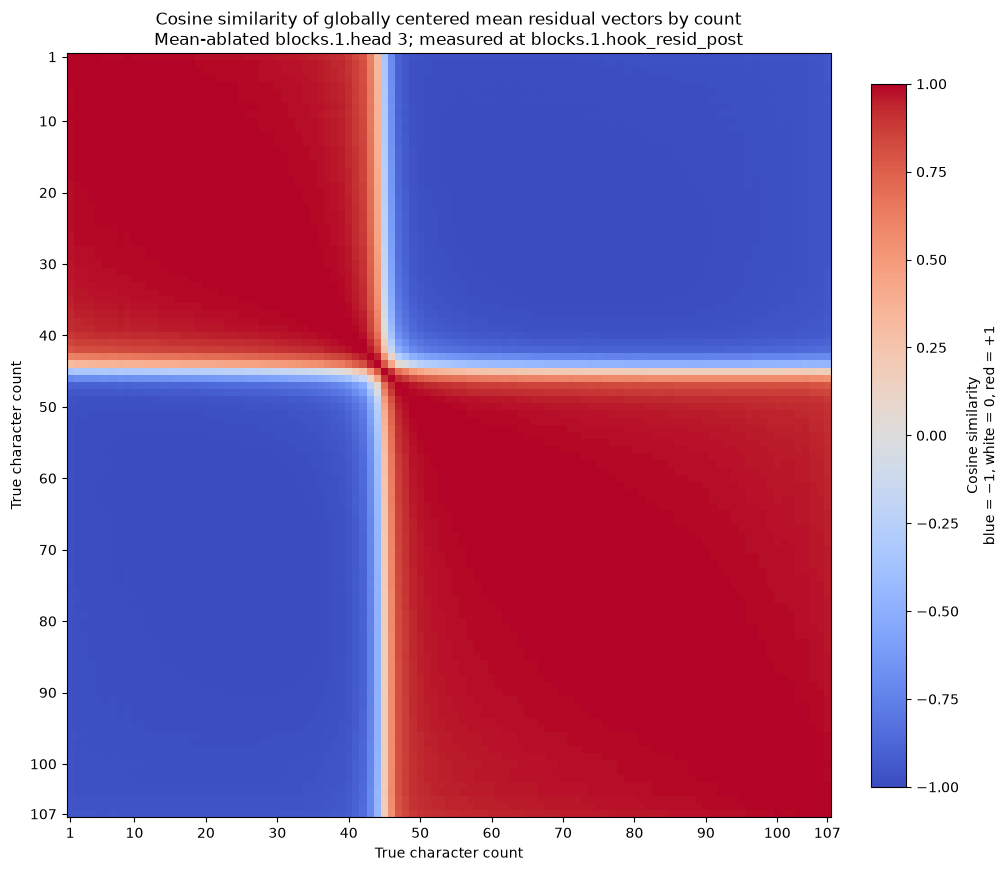

In [24]:
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
image = ax.imshow(
    ablated_residual_cosine_similarity,
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    origin="upper",
    interpolation="nearest",
    extent=(
        0.5,
        max_character_count + 0.5,
        max_character_count + 0.5,
        0.5,
    ),
    aspect="equal",
)

tick_values = np.unique(
    np.r_[1, np.arange(10, max_character_count + 1, 10), max_character_count]
)
ax.set_xticks(tick_values)
ax.set_yticks(tick_values)
ax.set_xlabel("True character count")
ax.set_ylabel("True character count")
ax.set_title(
    "Cosine similarity of globally centered mean residual vectors by count\n"
    f"Mean-ablated blocks.{ABLATE_LAYER}.head {ABLATE_HEAD}; "
    f"measured at {RESIDUAL_SITE}"
)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Cosine similarity\nblue = −1, white = 0, red = +1")
plt.show()